In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
from optuna.exceptions import ExperimentalWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ExperimentalWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import numpy as np
import pandas as pd
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import psutil
import torch
import pickle
from sklearn.linear_model import LogisticRegression

from pyspark.sql import SparkSession

from replay.utils.session_handler import get_spark_session, State

from replay.models import UCB, RandomRec
from replay.models.lin_ucb import LinUCB
from replay.models.lin_ts import LinTS
from replay.models import UCB, RandomRec, LinUCB, LinTS
from replay.experimental.scenarios.movielens_wrapper.replay_offline import OBPOfflinePolicyLearner
from replay.experimental.scenarios.jester_wrapper.dataset_jester import JesterBanditDataset
from replay.experimental.scenarios.movielens_wrapper.utils import get_est_rewards_by_reg, bandit_subset
from replay.utils.spark_utils import convert2spark

# from obp.policy import IPWLearner
from obp.ope import (
    OffPolicyEvaluation,
    DirectMethod,
    InverseProbabilityWeighting,
    DoublyRobust,
    SelfNormalizedInverseProbabilityWeighting,
    SelfNormalizedDoublyRobust,
)

from replay.experimental.scenarios.movielens_wrapper.modified_ips import Exp_Smooth_IPS_Min, Exp_Smooth_IPS_Max

'nlp' extra dependecy package 'gensim' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependecy package 'nltk' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependecy package 'transformers' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependecy package 'gensim' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependecy package 'nltk' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependecy package 'transformers' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.


In [5]:
spark = State(get_spark_session()).session
spark.sparkContext.setLogLevel('ERROR')

24/10/26 13:38:22 WARN Utils: Your hostname, sudakovcom-MS-7D48 resolves to a loopback address: 127.0.1.1; using 10.255.173.26 instead (on interface enp3s0)
24/10/26 13:38:22 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/10/26 13:38:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
24/10/26 13:38:26 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


In [6]:
print('momory usage:', psutil.virtual_memory().percent)

momory usage: 5.2


In [7]:
from rs_datasets import Jester

dataset = Jester()
data = dataset.data1
# data = pd.concat([dataset.data1, dataset.data2, dataset.data3])

In [8]:
data

,1,2,3,4,5,6,7,8,9,10,...,91,92,93,94,95,96,97,98,99,100
0,-7.82,8.79,-9.66,-8.16,-7.52,-8.50,-9.85,4.17,-8.98,-4.76,...,2.82,NaN,NaN,NaN,NaN,NaN,-5.63,NaN,NaN,NaN
1,4.08,-0.29,6.36,4.37,-2.38,-9.66,-0.73,-5.34,8.88,9.22,...,2.82,-4.95,-0.29,7.86,-0.19,-2.14,3.06,0.34,-4.32,1.07
2,NaN,NaN,NaN,NaN,9.03,9.27,9.03,9.27,NaN,NaN,...,NaN,NaN,NaN,9.08,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,8.35,NaN,NaN,1.80,8.16,-2.82,6.21,NaN,1.84,...,NaN,NaN,NaN,0.53,NaN,NaN,NaN,NaN,NaN,NaN
4,8.50,4.61,-4.17,-5.39,1.36,1.60,7.04,4.61,-0.44,5.73,...,5.19,5.58,4.27,5.19,5.73,1.55,3.11,6.55,1.80,1.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24978,0.44,7.43,9.08,2.33,3.20,6.75,-8.79,-0.53,-8.74,7.23,...,8.83,-1.21,9.22,-6.70,8.45,9.03,6.55,8.69,8.79,7.43
24979,9.13,-8.16,8.59,9.08,0.87,-8.93,-3.50,5.78,-8.11,4.90,...,-1.17,-5.73,-1.46,0.24,9.22,-8.20,-7.23,-8.59,9.13,8.45
24980,NaN,NaN,NaN,NaN,-7.77,NaN,6.70,-6.75,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24981,NaN,NaN,NaN,NaN,-9.71,NaN,4.56,-8.30,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# logs = {'user_id' : [], 'item_id': [], 'rating': [], 'timestamp': []}

# for user in tqdm(range(data.shape[0])):
#     row = data.iloc[user]
#     for item in range(1, 101):
#         rate = row[item]
#         if rate == rate:
#             logs['user_id'].append(user)
#             logs['item_id'].append(item)
#             logs['rating'].append(rate)
#             logs['timestamp'].append(0)
            
    
# logs = pd.DataFrame.from_dict(logs)
# logs = logs.sample(frac=1)
# logs['timestamp'] = np.arange(logs.shape[0])
# logs.to_csv('logs.csv', index=False)

logs = pd.read_csv('logs.csv')

In [10]:
logs

,user_id,item_id,rating,timestamp
0,15863,31,8.83,0
1,1405,100,7.04,1
2,10996,24,-2.82,2
3,3741,98,-2.91,3
4,1906,98,1.55,4
...,...,...,...,...
1810450,19633,26,8.35,1810450
1810451,13906,6,-6.94,1810451
1810452,19239,3,-8.54,1810452
1810453,17330,14,-6.12,1810453


In [11]:
size = len(sorted(logs['rating'].tolist()))
sorted(logs['rating'].tolist())[int(size*0.66)]

3.74

In [12]:
U, s, Vh = np.linalg.svd(np.nan_to_num((data.to_numpy()*0 + 1), nan = 0).astype(int), full_matrices=False)

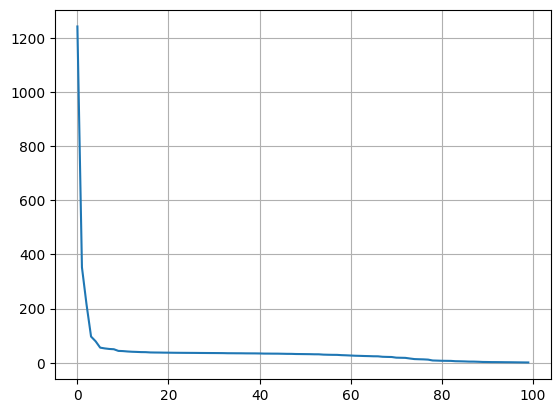

In [13]:
plt.plot(s)
plt.grid()
plt.show()

In [14]:
user_features = U[:, :5]
user_features = pd.DataFrame({'user_id': range(user_features.shape[0]), 'f0': user_features[:, 0], 'f1': user_features[:, 1], 'f2': user_features[:, 2], 'f3': user_features[:, 3], 'f4': user_features[:, 4]})

user_features

,user_id,f0,f1,f2,f3,f4
0,0,-0.006554,0.003245,-0.007728,-0.002993,0.003117
1,1,-0.007733,-0.007698,0.002910,0.000882,0.001953
2,2,-0.004529,0.006321,0.007690,0.000121,0.000211
3,3,-0.004512,0.007196,0.008323,0.003257,-0.005008
4,4,-0.007352,-0.004015,-0.001255,-0.004677,-0.018731
...,...,...,...,...,...,...
24978,24978,-0.007733,-0.007698,0.002910,0.000882,0.001953
24979,24979,-0.007352,-0.004014,-0.001266,-0.004684,-0.018530
24980,24980,-0.003771,0.007565,0.009261,-0.009688,0.005463
24981,24981,-0.003549,0.007081,0.010804,-0.012120,0.007368


In [15]:
# user_features = U[:, :20]
# user_features = pd.DataFrame({'user_id': range(user_features.shape[0]), 'f0': user_features[:, 0], 'f1': user_features[:, 1], 'f2': user_features[:, 2], 'f3': user_features[:, 3], 'f4': user_features[:, 4],
#                               'f5': user_features[:, 5], 'f6': user_features[:, 6], 'f7': user_features[:, 7], 'f8': user_features[:, 8], 'f9': user_features[:, 9],
#                               'f10': user_features[:, 10], 'f11': user_features[:, 11], 'f12': user_features[:, 12], 'f13': user_features[:, 13], 'f14': user_features[:, 14],
#                               'f15': user_features[:, 15], 'f16': user_features[:, 16], 'f17': user_features[:, 17], 'f18': user_features[:, 18], 'f19': user_features[:, 19]})

# user_features

In [16]:
item_features = {'item_id': range(1, 101), 'f': range(1, 101)}
item_features = pd.DataFrame(item_features)
item_features

,item_id,f
0,1,1
1,2,2
2,3,3
3,4,4
4,5,5
...,...,...
95,96,96
96,97,97
97,98,98
98,99,99


In [17]:
dataset = JesterBanditDataset(logs, user_features, item_features)

26-Oct-24 13:38:42, replay, INFO: Columns with ids of users or items are present in mapping. The dataframe will be treated as an interactions log.
INFO:replay:Columns with ids of users or items are present in mapping. The dataframe will be treated as an interactions log.
26-Oct-24 13:38:52, replay, INFO: Column with ids of users or items is absent in mapping. The dataframe will be treated as a users'/items' features dataframe.
INFO:replay:Column with ids of users or items is absent in mapping. The dataframe will be treated as a users'/items' features dataframe.
26-Oct-24 13:38:52, replay, INFO: Column with ids of users or items is absent in mapping. The dataframe will be treated as a users'/items' features dataframe.
INFO:replay:Column with ids of users or items is absent in mapping. The dataframe will be treated as a users'/items' features dataframe.


loading pretrained model


In [20]:
dataset.pscore

array([0.01361801, 0.0054925 , 0.00877065, ..., 0.00919212, 0.01243612,
       0.01376227])

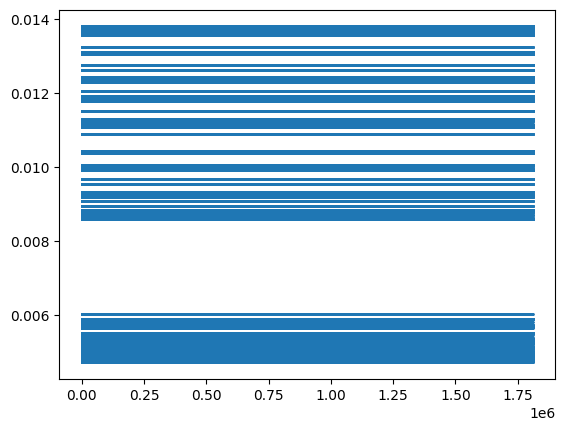

In [23]:
plt.scatter(np.arange(dataset.pscore.size), dataset.pscore, s = 1)

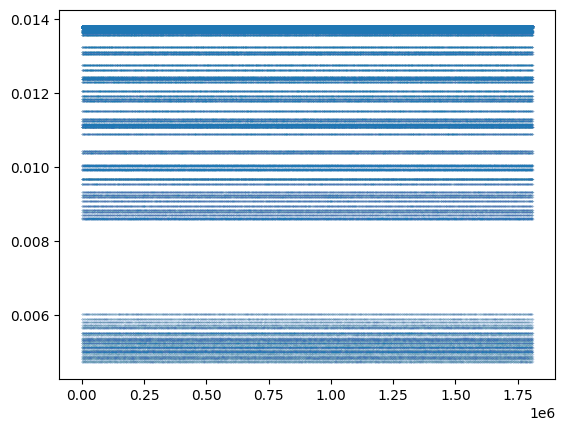

In [78]:
plt.scatter(np.arange(len(dataset.pscore)), dataset.pscore, s = 0.0001)
plt.show()

In [26]:
np.where(dataset.action == 0)

(array([     30,      72,     191, ..., 1810284, 1810373, 1810410]),)

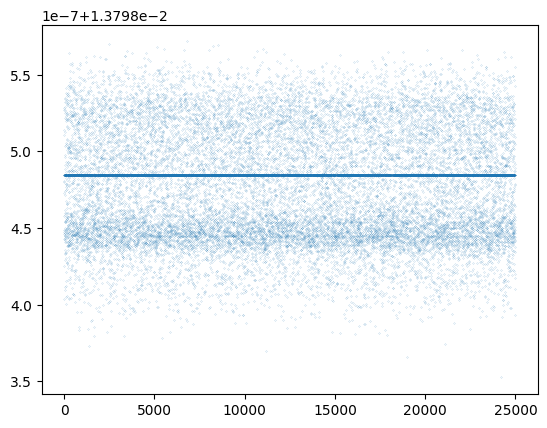

In [31]:
plt.scatter(np.arange(len(dataset.pscore[np.where(dataset.action == 0)])), dataset.pscore[np.where(dataset.action == 0)], s = 0.01)
plt.show()

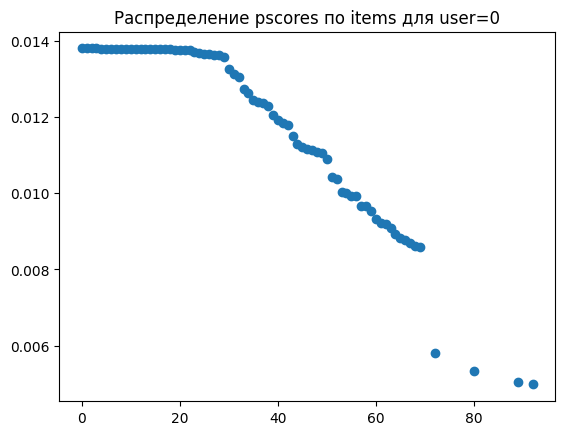

In [130]:
i = 0
plt.scatter(np.array(dataset.log.toPandas()['item_idx'].tolist())[np.where(np.array(dataset.logs['user_id'].tolist()) == i)], dataset.pscore[np.where(np.array(dataset.logs['user_id'].tolist()) == i)])
plt.title(f'Распределение pscores по items для user={i}')
plt.show()

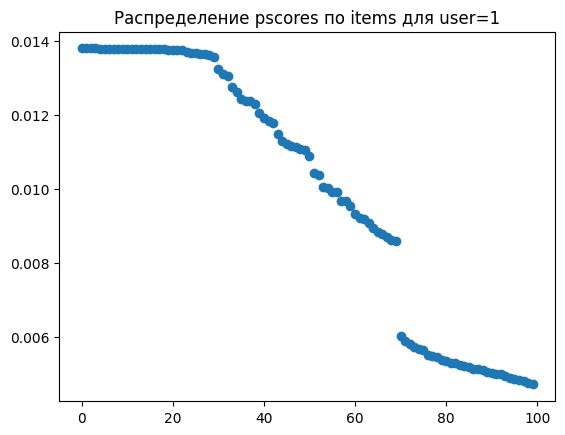

In [128]:
i = 1
plt.scatter(np.array(dataset.log.toPandas()['item_idx'].tolist())[np.where(np.array(dataset.logs['user_id'].tolist()) == i)], dataset.pscore[np.where(np.array(dataset.logs['user_id'].tolist()) == i)])
plt.title(f'Распределение pscores по items для user={i}')
plt.show()

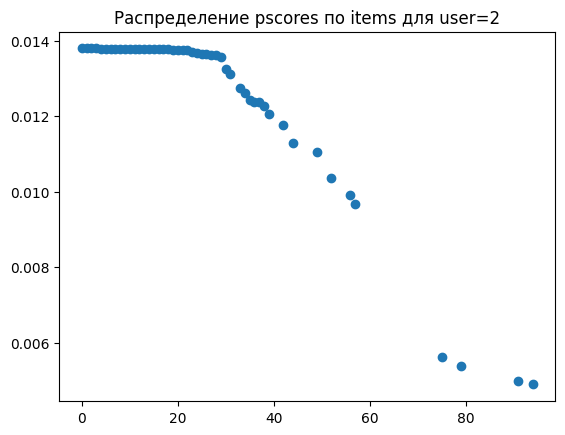

In [129]:
i = 2
plt.scatter(np.array(dataset.log.toPandas()['item_idx'].tolist())[np.where(np.array(dataset.logs['user_id'].tolist()) == i)], dataset.pscore[np.where(np.array(dataset.logs['user_id'].tolist()) == i)])
plt.title(f'Распределение pscores по items для user={i}')
plt.show()

In [69]:
dataset.context.shape

(1810455, 5)

In [70]:
bandit_feedback_train, bandit_feedback_test = dataset.obtain_batch_bandit_feedback(test_size=0.3, is_timeseries_split=True)
print('train_size:', bandit_feedback_train["n_rounds"])
print('test_size:', bandit_feedback_test["n_rounds"])

1267318 543137
train_size: 1267318
test_size: 543137


In [71]:
viewed_items = bandit_feedback_train["log"].toPandas().groupby("user_idx")["item_idx"].apply(list)

In [72]:
viewed_items

user_idx
0        [38, 64, 26, 57, 27, 58, 41, 70, 19, 23, 21, 6...
1        [98, 59, 47, 50, 82, 23, 64, 12, 7, 84, 53, 60...
2        [80, 16, 28, 26, 69, 81, 9, 97, 30, 58, 56, 92...
3        [87, 95, 12, 14, 33, 66, 44, 10, 48, 92, 24, 1...
4        [31, 24, 57, 68, 55, 79, 59, 52, 33, 32, 98, 2...
                               ...                        
24978    [9, 3, 19, 5, 10, 74, 29, 12, 22, 18, 37, 2, 2...
24979    [7, 11, 23, 28, 5, 6, 30, 21, 2, 82, 64, 17, 1...
24980    [29, 74, 22, 27, 25, 10, 14, 38, 9, 12, 32, 6,...
24981    [4, 23, 50, 28, 16, 29, 0, 22, 6, 11, 10, 15, ...
24982    [38, 37, 10, 19, 5, 51, 2, 12, 48, 0, 6, 20, 1...
Name: item_idx, Length: 24983, dtype: object

In [73]:
n_users = user_features.shape[0]
n_users

24983

In [74]:
viewed_items_all = { i: viewed_items[i] if i in viewed_items.index else [] for i in range(n_users)}

In [75]:
viewed_items_for_test = [viewed_items_all[item_idx] for item_idx in bandit_feedback_test['log'].toPandas()['user_idx'].values]

In [76]:
len(viewed_items_for_test)

543137

In [77]:
viewed_items_for_test = np.array(viewed_items_for_test)

In [78]:
viewed_items_for_test

array([list([11, 73, 29, 9, 79, 14, 35, 63, 31, 54, 48, 59, 70, 38, 68, 67, 60, 57, 1, 4, 25, 46, 30, 50, 80, 84, 89, 37, 42, 44, 82, 52, 74, 32, 69, 33, 3, 81, 12, 5, 61, 62, 6, 51, 66, 16, 20, 13, 77, 0, 43, 56, 45, 47, 40, 78, 65, 28, 22, 55, 19]),
       list([17, 52, 6, 9, 1, 97, 24, 34, 16, 41, 99, 36, 15, 32, 51, 3, 0, 8, 35, 38, 44, 4, 54, 78, 59, 53, 25, 10, 60, 18, 48, 22, 7, 49, 12, 56, 47, 21, 2, 37, 39, 61, 29, 43]),
       list([79, 10, 43, 72, 8, 12, 95, 52, 32, 64, 92, 65, 90, 60, 25, 37, 84, 63, 38, 55, 1, 5, 99, 20, 66, 35, 4, 18, 41, 74, 15, 7, 39, 76, 75, 73, 77, 29, 94, 86, 71, 22, 82, 17, 40, 50, 62, 46, 56, 45, 97, 0, 93, 26, 27, 61, 30, 80, 16, 68, 47, 21]),
       ...,
       list([44, 20, 25, 1, 27, 17, 54, 57, 39, 8, 14, 46, 82, 15, 23, 11, 24, 35, 26, 58, 52, 40, 50, 36, 43, 30, 60, 16, 5, 33, 47, 4, 41, 18, 61, 31, 7, 2, 56, 21, 12, 13, 49, 48, 29, 34]),
       list([61, 76, 83, 77, 27, 57, 55, 63, 97, 75, 24, 74, 10, 73, 43, 49, 36, 30, 79, 40, 82, 5, 65, 

<!--  estimated_rewards_by_reg_model считается по pscores обученным без регуляризации-->

In [79]:
estimated_rewards_by_reg_model = get_est_rewards_by_reg(bandit_feedback_train['n_actions'],
                                                        dataset.len_list,
                                                        bandit_feedback_train,
                                                        bandit_feedback_test)

In [80]:
param_borders_1 = {
    "coef": [0, 10],
}
param_borders_2 = {
    "eps": [-10, 10],
    "alpha": [0.001, 10]
}
param_borders_3 = {
    "distribution": ["popular_based", "relevance"],
    "alpha": [-0.5, 1000],
}
param_borders_4 = {
    "nu": [0.001, 10],
    "alpha": [100, 1500]
}

model_1 = UCB(exploration_coef = 0.019690161005879007, sample = True, seed = 123)
learner_1 = OBPOfflinePolicyLearner(n_actions=dataset.n_actions,
                                    replay_model=model_1)

model_2 = LinUCB(eps = -9.72489048220909, alpha = 0.09254311517041612, regr_type = 'disjoint')
learner_2 = OBPOfflinePolicyLearner(n_actions=dataset.n_actions,
                                    replay_model=model_2)

model_3 = RandomRec(distribution = 'relevance', alpha = 153.974492960275, seed=42)
learner_3 = OBPOfflinePolicyLearner(n_actions=dataset.n_actions,
                                    replay_model=model_3)

model_4 = LinTS(nu = 9.585195706830213, alpha = 140.03084149742904, regr_type = 'disjoint')
learner_4 = OBPOfflinePolicyLearner(n_actions=dataset.n_actions,
                                    replay_model=model_4)

model_5 = RandomRec()
learner_5 = OBPOfflinePolicyLearner(n_actions=dataset.n_actions,
                                    replay_model=model_5)

In [81]:
def get_dist(learner):
    all_action_dist = np.zeros((bandit_feedback_test["n_rounds"], bandit_feedback_test["n_actions"], 1))
    if isinstance(learner.replay_model, (LinUCB, LinTS)):
        log_distinct = bandit_feedback_test['log'].toPandas().drop_duplicates(subset=["user_idx"], keep='first')
        users_all = bandit_feedback_test['log'].toPandas()['user_idx'].tolist()
        batch_size = 10
        num_batchs = log_distinct.shape[0] // batch_size
        for batch_idx in tqdm(range(num_batchs+1)):
            j = min((batch_idx+1)*batch_size, log_distinct.shape[0])
            if j == batch_idx*batch_size:
                break
            log_subset = log_distinct.iloc[batch_idx*batch_size: j]
            n_rounds = log_subset.shape[0]
            
            action_dist = learner.predict(n_rounds, convert2spark(log_subset).select('user_idx'))

            users_distinct = log_subset['user_idx'].tolist()

            user2ind = {}
            for i in range(n_rounds):
                user2ind[users_distinct[i]] = i

            for i in range(bandit_feedback_test["n_rounds"]):
                if users_all[i] in users_distinct:
                    all_action_dist[i] = action_dist[user2ind[users_all[i]]]

    else:
        batch_size = 300
        num_batchs = bandit_feedback_test["n_rounds"] // batch_size
        for batch_idx in tqdm(range(num_batchs+1)):
            j = min((batch_idx+1)*batch_size, bandit_feedback_test["n_rounds"])
            if j == batch_idx*batch_size:
                break
            bandit_feedback_subset = bandit_subset([batch_idx*batch_size, j], bandit_feedback_test) #The first parameter is a slice of subset [a, b]
            action_dist = learner.predict(bandit_feedback_subset["n_rounds"], bandit_feedback_subset["log"].select('user_idx'))
            all_action_dist[batch_idx*batch_size:j] = action_dist
    return all_action_dist

In [82]:
bandit_feedback_optimize = bandit_subset([0, 100000], bandit_feedback_train)

In [93]:
# learner_1.optimize(bandit_feedback_optimize, val_size=0.3, param_borders=param_borders_1, budget=20)

In [94]:
learner_1.fit(bandit_feedback_train)
all_action_dist_1 = get_dist(learner_1)

100%|██████████| 1811/1811 [05:54<00:00,  5.10it/s]


In [95]:
# learner_2.optimize(bandit_feedback_optimize, val_size=0.3, param_borders=param_borders_2, budget=20)

In [96]:
learner_2.fit(bandit_feedback_train)
all_action_dist_2 = get_dist(learner_2)

100%|██████████| 2499/2499 [12:13<00:00,  3.41it/s]


In [97]:
# learner_3.optimize(bandit_feedback_optimize, val_size=0.3, param_borders=param_borders_3, budget=20)

In [98]:
learner_3.fit(bandit_feedback_train)
all_action_dist_3 = get_dist(learner_3)

100%|██████████| 1811/1811 [07:13<00:00,  4.17it/s]


In [99]:
learner_5.fit(bandit_feedback_train)
all_action_dist_5 = get_dist(learner_5)

100%|██████████| 1811/1811 [07:12<00:00,  4.19it/s]


In [101]:
np.save(f'UCB_policy', all_action_dist_1)
np.save(f'Lin_UCB_policy', all_action_dist_2)
np.save(f'Random_policy', all_action_dist_3)
np.save(f'Random_policy_uniform', all_action_dist_5)

In [48]:
np.save(f'Random_policy_uniform', all_action_dist_5)

In [83]:
all_action_dist_1 = np.load(f'UCB_policy.npy')
all_action_dist_2 = np.load(f'Lin_UCB_policy.npy')
all_action_dist_3 = np.load(f'Random_policy.npy')

In [84]:
def plot_user_dist(action_dist, user):
    plt.scatter(np.arange(action_dist[user][:, 0].size), action_dist[user][:, 0])

In [139]:
model_2 = LinUCB(eps = 0, alpha = 0.09254311517041612, regr_type = 'disjoint')
learner_2 = OBPOfflinePolicyLearner(n_actions=dataset.n_actions,
                                    replay_model=model_2)

learner_2.fit(bandit_feedback_train)
all_action_dist_2 = get_dist(learner_2)

100%|██████████| 2499/2499 [12:19<00:00,  3.38it/s]


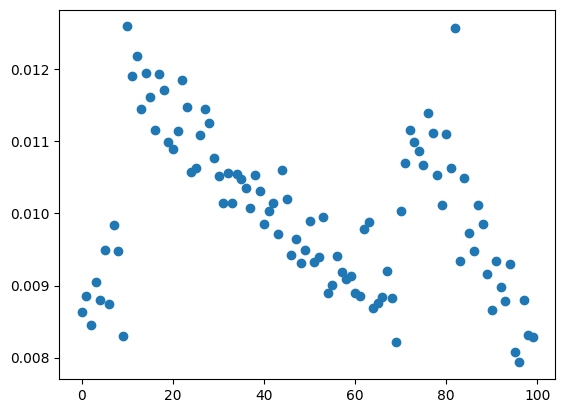

In [140]:
plot_user_dist(all_action_dist_2, 0)

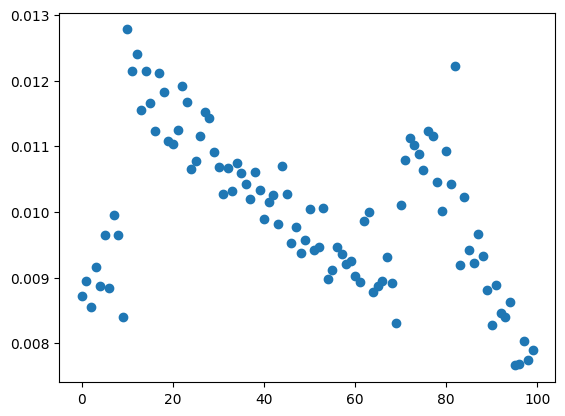

In [141]:
plot_user_dist(all_action_dist_2, 1)

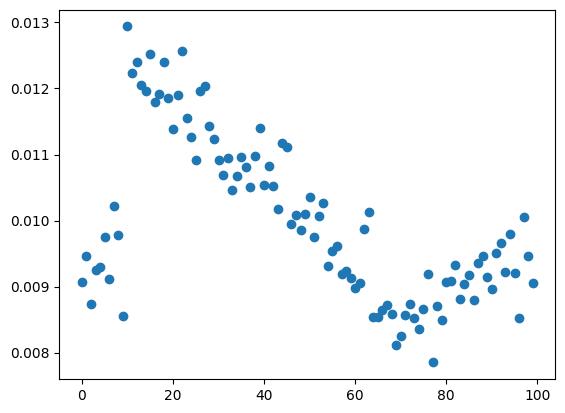

In [142]:
plot_user_dist(all_action_dist_2, 2)

In [143]:
model_2 = LinUCB(eps = -2, alpha = 0.09254311517041612, regr_type = 'disjoint')
learner_2 = OBPOfflinePolicyLearner(n_actions=dataset.n_actions,
                                    replay_model=model_2)

learner_2.fit(bandit_feedback_train)
all_action_dist_2 = get_dist(learner_2)

100%|██████████| 2499/2499 [16:34<00:00,  2.51it/s]


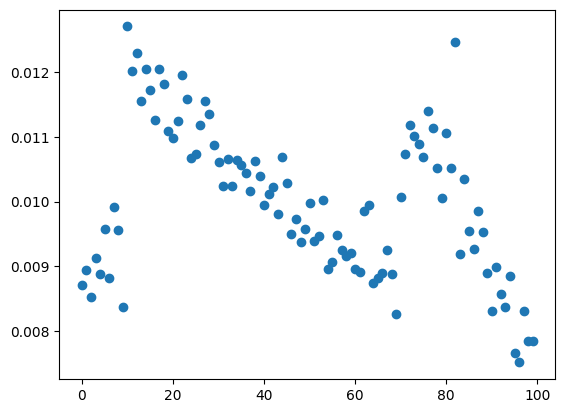

In [144]:
plot_user_dist(all_action_dist_2, 0)

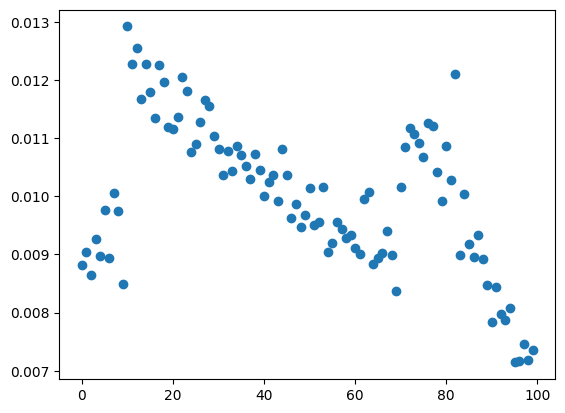

In [145]:
plot_user_dist(all_action_dist_2, 1)

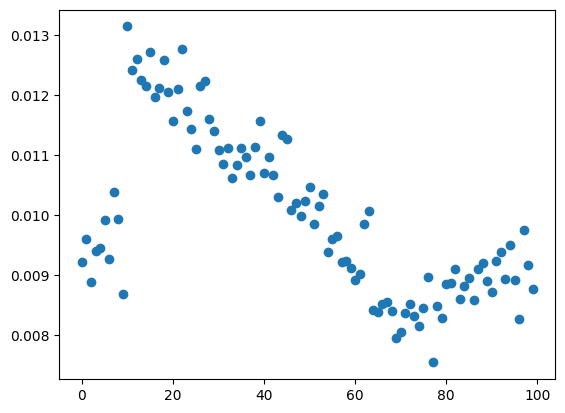

In [146]:
plot_user_dist(all_action_dist_2, 2)

In [147]:
model_2 = LinUCB(eps = -5, alpha = 0.09254311517041612, regr_type = 'disjoint')
learner_2 = OBPOfflinePolicyLearner(n_actions=dataset.n_actions,
                                    replay_model=model_2)

learner_2.fit(bandit_feedback_train)
all_action_dist_2 = get_dist(learner_2)

100%|██████████| 2499/2499 [21:19<00:00,  1.95it/s]                             


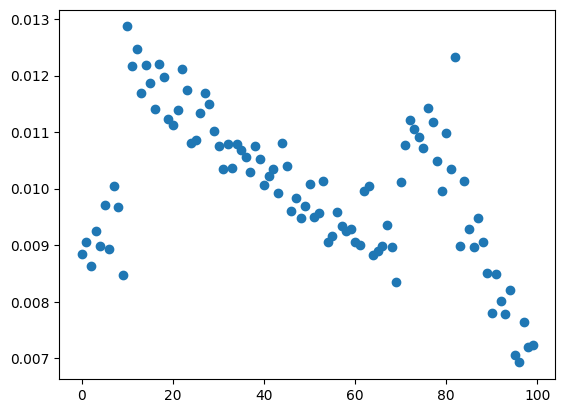

In [148]:
plot_user_dist(all_action_dist_2, 0)

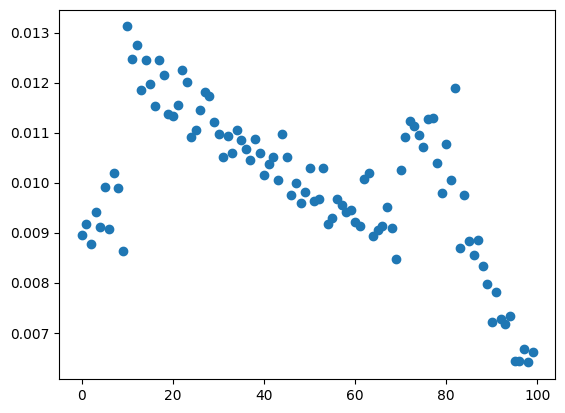

In [149]:
plot_user_dist(all_action_dist_2, 1)

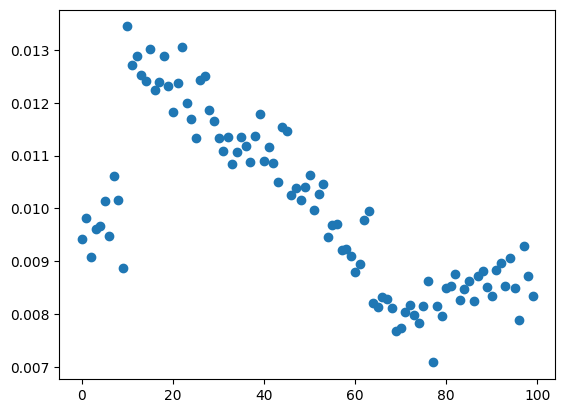

In [150]:
plot_user_dist(all_action_dist_2, 2)

In [151]:
model_2 = LinUCB(eps = -10, alpha = 0.09254311517041612, regr_type = 'disjoint')
learner_2 = OBPOfflinePolicyLearner(n_actions=dataset.n_actions,
                                    replay_model=model_2)

learner_2.fit(bandit_feedback_train)
all_action_dist_2 = get_dist(learner_2)

100%|██████████| 2499/2499 [25:53<00:00,  1.61it/s]                             


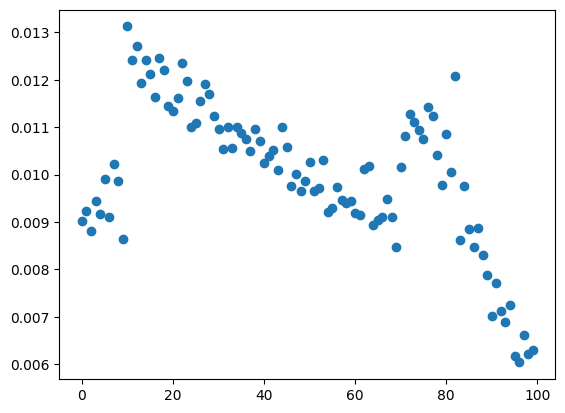

In [152]:
plot_user_dist(all_action_dist_2, 0)

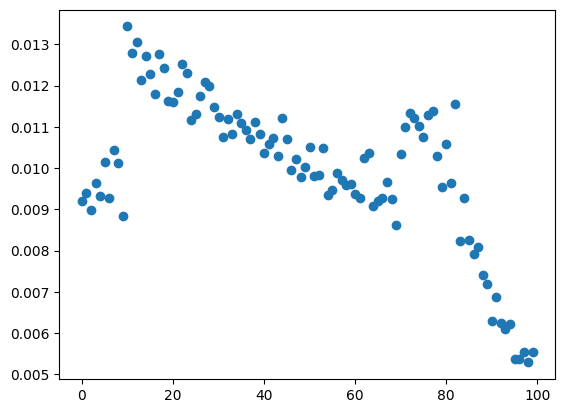

In [153]:
plot_user_dist(all_action_dist_2, 1)

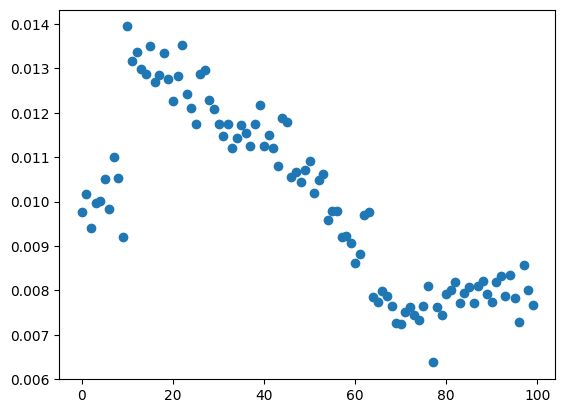

In [154]:
plot_user_dist(all_action_dist_2, 2)

In [155]:
model_2 = LinUCB(eps = -20, alpha = 0.09254311517041612, regr_type = 'disjoint')
learner_2 = OBPOfflinePolicyLearner(n_actions=dataset.n_actions,
                                    replay_model=model_2)

learner_2.fit(bandit_feedback_train)
all_action_dist_2 = get_dist(learner_2)

100%|██████████| 2499/2499 [31:18<00:00,  1.33it/s]                             


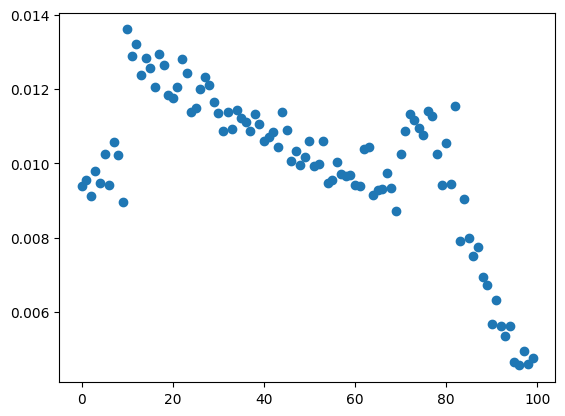

In [156]:
plot_user_dist(all_action_dist_2, 0)

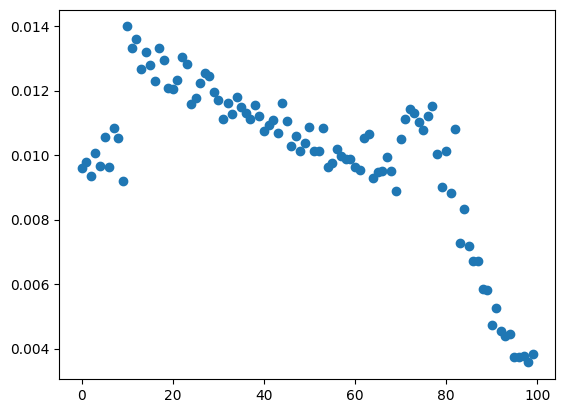

In [157]:
plot_user_dist(all_action_dist_2, 1)

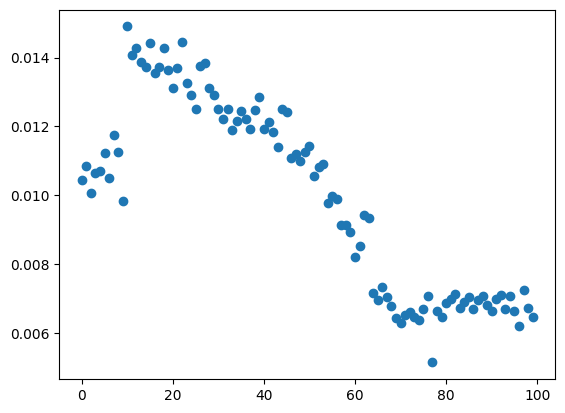

In [158]:
plot_user_dist(all_action_dist_2, 2)

In [159]:
model_2 = LinUCB(eps = -50, alpha = 0.09254311517041612, regr_type = 'disjoint')
learner_2 = OBPOfflinePolicyLearner(n_actions=dataset.n_actions,
                                    replay_model=model_2)

learner_2.fit(bandit_feedback_train)
all_action_dist_2 = get_dist(learner_2)

100%|██████████| 2499/2499 [35:23<00:00,  1.18it/s]                             


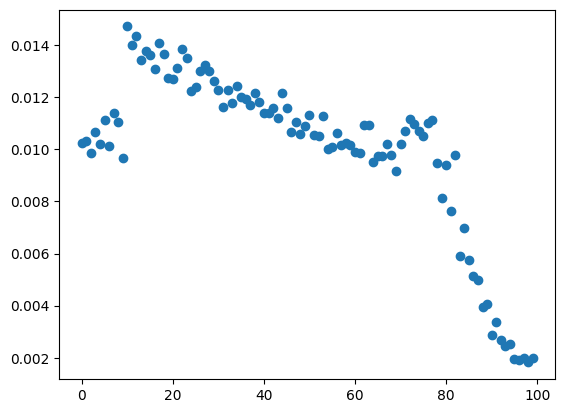

In [160]:
plot_user_dist(all_action_dist_2, 0)

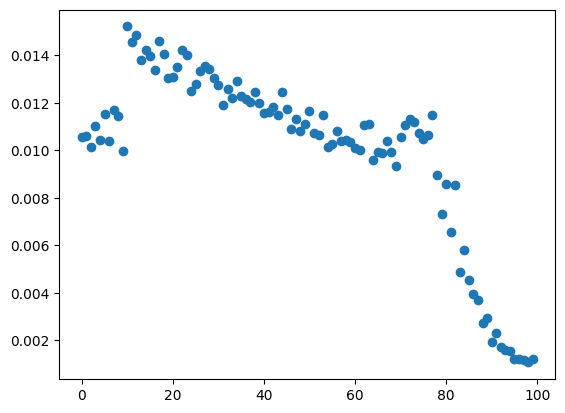

In [161]:
plot_user_dist(all_action_dist_2, 1)

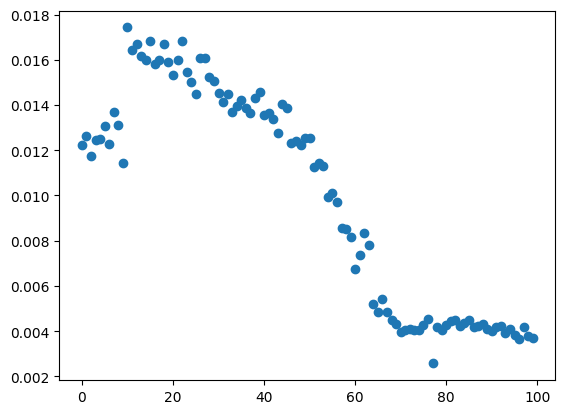

In [162]:
plot_user_dist(all_action_dist_2, 2)

In [165]:
model_2 = LinUCB(eps = 10, alpha = 0.09254311517041612, regr_type = 'disjoint')
learner_2 = OBPOfflinePolicyLearner(n_actions=dataset.n_actions,
                                    replay_model=model_2)

learner_2.fit(bandit_feedback_train)
all_action_dist_2 = get_dist(learner_2)

100%|██████████| 2499/2499 [39:58<00:00,  1.04it/s]                             


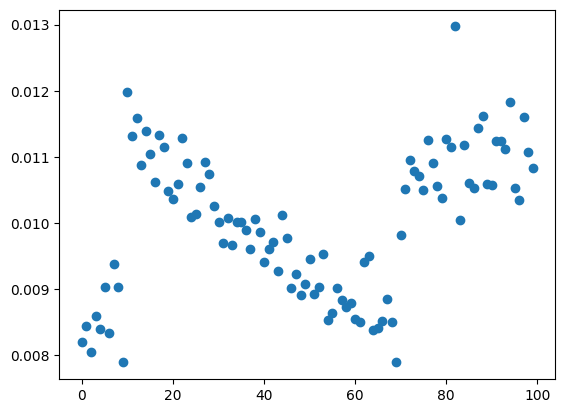

In [166]:
plot_user_dist(all_action_dist_2, 0)

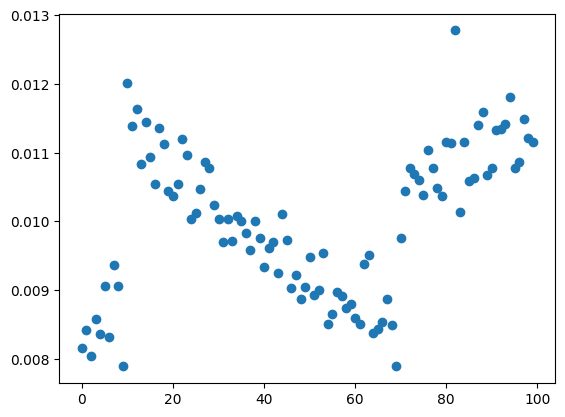

In [167]:
plot_user_dist(all_action_dist_2, 1)

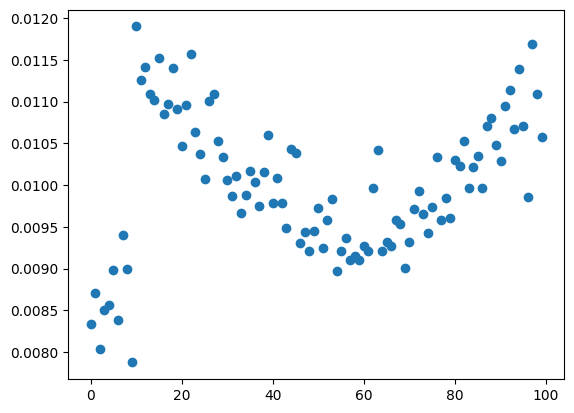

In [168]:
plot_user_dist(all_action_dist_2, 2)

In [89]:
# plot_user_dist(all_action_dist_5, 0)

In [90]:
print('momory usage:', psutil.virtual_memory().percent)

momory usage: 17.1


In [91]:
new_log = dataset.log.toPandas().copy()
map_pop_dist = new_log['item_idx'].value_counts(normalize=True)
pop_dist = map_pop_dist.loc[dataset.action].values
pop_dist_test = map_pop_dist.loc[bandit_feedback_test['action']].values

In [92]:
any_dist = np.random.rand(bandit_feedback_test['n_actions'])
any_dist = np.exp(any_dist)/ np.exp(any_dist).sum()
any_dist_test = np.array([any_dist[i] for i in bandit_feedback_test['action']])
any_dist_train = np.array([any_dist[i] for i in dataset.action])

In [93]:
any_dist_train.shape

(1810455,)

In [94]:
# def CrossEntropyLoss_my(pred, labels, kl_dist, pop_dist, alpha):
#     log_loss = torch.nn.functional.cross_entropy(pred,labels)
#     probs = torch.nn.functional.softmax(pred, dim=1)
#     my_reg = (((kl_dist/ probs)[np.arange(labels.shape[0]), labels].sum() - 1)**2 + ((pop_dist / probs[np.arange(labels.shape[0]), labels]).sum() - 1)**2)/(2 * labels.shape[0]**2)
    # kl_reg = torch.mean(torch.sum((kl_dist * torch.log(kl_dist/torch.nn.functional.softmax(pred, dim=1))), dim=1))
    # return log_loss + alpha * my_reg

def CrossEntropyLoss_oh(pred, labels, dist, alpha):
    log_loss = torch.nn.functional.cross_entropy(pred,labels)
    kl_reg = torch.mean(torch.sum((dist * torch.log(dist/torch.nn.functional.softmax(pred, dim=1))), dim=1))
    return log_loss + alpha * kl_reg

class my_Model(torch.nn.Module):
    def __init__(self, cnt_feat, num_classes):
        super().__init__()
        self.lin = torch.nn.Sequential(
            torch.nn.Linear(cnt_feat, num_classes, bias=True)           
        )
    def forward(self, x):
        return self.lin(x)

class Behavior_Clone_Model:
    def __init__(self, cnt_feat, num_classes, lr, n_epochs, batch_size, alpha):
        self.n_epochs = n_epochs  # epochs
        self.lr = lr  # learning rate
        self.batch_size = batch_size #batch_size
        self.alpha = alpha #param of regul
        # model
        self.model = my_Model(cnt_feat, num_classes)
        self.num_classes = num_classes

    def fit(self, x_train, Y_train, x_test, Y_test):
        
        dist_batch = torch.FloatTensor(np.ones((self.batch_size, self.num_classes)) * (1/self.num_classes))
        dist_test = torch.FloatTensor(np.ones((Y_test.shape[0], self.num_classes))* (1/self.num_classes))
        # training graph and optimization
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        # loss and accuracy storage
        cnt_batch_per_epoch = Y_train.size//self.batch_size
        self.model.train()
        for step in range(self.n_epochs*cnt_batch_per_epoch + 1):
            # randomic batch definition
            rbatch = np.random.choice(Y_train.size, size=self.batch_size)
            # variables initialization
            X = torch.autograd.Variable(torch.FloatTensor(x_train[rbatch]))
            Y = torch.LongTensor(Y_train[rbatch].astype(np.int))
            # training, metrics and storage
            optimizer.zero_grad()
            pred = self.model(X)
            L = CrossEntropyLoss_oh(pred, Y, dist_batch, self.alpha)
            L.backward()
            optimizer.step()

            if step%1000 == 0:
                self.model.eval()
                with torch.no_grad():
                    X_ = torch.autograd.Variable(torch.FloatTensor(x_test))
                    pred_test = self.model(X_)
                    Y_ = torch.LongTensor(Y_test)
                    loss_test = CrossEntropyLoss_oh(pred_test, Y_, dist_test, self.alpha)
                    print('step', step, 'ce_loss_test: ', loss_test.detach())
                print('step: {0:04d} | loss: {1:.3f}'.format(step, L))
    
    def predict_proba(self, x_test, Y_test):
        self.model.eval()
        with torch.no_grad():
            X_ = torch.autograd.Variable(torch.FloatTensor(x_test))
            probs = torch.nn.functional.softmax(self.model(X_), dim=1).detach().numpy()
        print('acc: ',(np.argmax(probs, axis = 1) == Y_test).mean())
        return probs[np.arange(Y_test.size), Y_test]

In [40]:
num_polices = 5

In [111]:
num_polices = 25

In [137]:
context_train = dataset.context
action_train = dataset.action
size_subset = int(0.8*context_train.shape[0])
alpha = 50
b_model = Behavior_Clone_Model(context_train.shape[1], bandit_feedback_train['n_actions'], 1e-4, 10, 64, alpha)
b_model.fit(context_train, action_train, bandit_feedback_test['context'][:100000], bandit_feedback_test['action'][:100000])
p_0 = b_model.predict_proba(bandit_feedback_test['context'], bandit_feedback_test['action'])

step 0 ce_loss_test:  tensor(6.3511)
step: 0000 | loss: 6.317
step 1000 ce_loss_test:  tensor(5.4830)
step: 1000 | loss: 5.472
step 2000 ce_loss_test:  tensor(5.0129)
step: 2000 | loss: 5.018
step 3000 ce_loss_test:  tensor(4.7696)
step: 3000 | loss: 4.771
step 4000 ce_loss_test:  tensor(4.6577)
step: 4000 | loss: 4.657
step 5000 ce_loss_test:  tensor(4.6164)
step: 5000 | loss: 4.617
step 6000 ce_loss_test:  tensor(4.6058)
step: 6000 | loss: 4.607
step 7000 ce_loss_test:  tensor(4.6043)
step: 7000 | loss: 4.604
step 8000 ce_loss_test:  tensor(4.6042)
step: 8000 | loss: 4.603
step 9000 ce_loss_test:  tensor(4.6042)
step: 9000 | loss: 4.604
step 10000 ce_loss_test:  tensor(4.6042)
step: 10000 | loss: 4.604
step 11000 ce_loss_test:  tensor(4.6042)
step: 11000 | loss: 4.605
step 12000 ce_loss_test:  tensor(4.6042)
step: 12000 | loss: 4.605
step 13000 ce_loss_test:  tensor(4.6042)
step: 13000 | loss: 4.603
step 14000 ce_loss_test:  tensor(4.6042)
step: 14000 | loss: 4.604
step 15000 ce_loss

In [207]:
# context_train = dataset.context
# action_train = dataset.action
# size_subset = int(0.8*context_train.shape[0])
# for alpha in [0,  1e-2, 1e-1, 1, 5, 10]:
#     behavior_policies = []
#     print(alpha, 'start')
#     for i in range(num_polices):
#         print(i,"start")
#         bootstrap_idx = np.random.choice(context_train.shape[0], size=size_subset)
#         b_model = Behavior_Clone_Model(context_train.shape[1], bandit_feedback_train['n_actions'], 1e-4, 4, 64, alpha)
#         b_model.fit(context_train[bootstrap_idx], action_train[bootstrap_idx], bandit_feedback_test['context'][:100000], bandit_feedback_test['action'][:100000])
#         torch.save(b_model.model.state_dict(), f'./models_pi_0_without_id_my_reg_mean_any_dist/model_{i}_alpha_{alpha}.pt')
#         behavior_policies.append(b_model.predict_proba(bandit_feedback_test['context'], bandit_feedback_test['action']))
#     behavior_policies_np = np.array(behavior_policies)
#     np.save(f'behavior_policies_full_without_id_my_reg_mean_any_dist_np_25_alpha={alpha}', behavior_policies_np)

In [112]:
context_train = dataset.context
action_train = dataset.action
size_subset = int(0.8*context_train.shape[0])
for alpha in [0]:
    behavior_policies = []
    print(alpha, 'start')
    for i in tqdm(range(num_polices)):
        bootstrap_idx = np.random.choice(context_train.shape[0], size=size_subset)
        b_model = LogisticRegression(max_iter=100, random_state=12345, n_jobs=-1)
        b_model.fit(context_train[bootstrap_idx], action_train[bootstrap_idx])
        with open(f'./sklearn_models/model_{i}_alpha_{alpha}.pkl','wb') as f:
            pickle.dump(b_model,f)
        print(b_model.predict_proba(bandit_feedback_test['context']).shape)
        behavior_policies.append(b_model.predict_proba(bandit_feedback_test['context'])[np.arange(bandit_feedback_test['action'].size), bandit_feedback_test['action']])
    behavior_policies_np = np.array(behavior_policies)
    np.save(f'./sklearn_models/behavior_policies_sklearn_25_alpha={alpha}', behavior_policies_np)

0 start


  0%|          | 0/25 [00:00<?, ?it/s]

INFO:root:Exception while sending command.
Traceback (most recent call last):
  File "/home/sudakovcom/Desktop/RePlayHDILab2024/.conda/lib/python3.8/site-packages/py4j/clientserver.py", line 503, in send_command
    self.socket.sendall(command.encode("utf-8"))
ConnectionResetError: [Errno 104] Connection reset by peer

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/sudakovcom/Desktop/RePlayHDILab2024/.conda/lib/python3.8/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/home/sudakovcom/Desktop/RePlayHDILab2024/.conda/lib/python3.8/site-packages/py4j/clientserver.py", line 506, in send_command
    raise Py4JNetworkError(
py4j.protocol.Py4JNetworkError: Error while sending


(543137, 100)


  4%|▍         | 1/25 [01:03<25:31, 63.83s/it]

...

 92%|█████████▏| 23/25 [24:12<02:04, 62.33s/it]

(543137, 100)


 96%|█████████▌| 24/25 [25:16<01:02, 62.79s/it]

(543137, 100)


100%|██████████| 25/25 [26:20<00:00, 63.22s/it]


In [100]:
bandit_feedback_test['log'].toPandas()

,user_idx,item_idx,relevance,timestamp,pscore
0,8190,41,1,1970-01-01 03:00:09,0.011839
1,15875,31,0,1970-01-01 03:00:10,0.013117
2,2038,11,0,1970-01-01 03:00:11,0.013793
3,2940,20,0,1970-01-01 03:00:12,0.013765
4,3819,30,1,1970-01-01 03:00:14,0.013250
...,...,...,...,...,...
543132,22915,9,0,1970-01-22 01:53:56,0.013795
543133,21790,21,0,1970-01-22 01:53:58,0.013762
543134,16872,55,0,1970-01-22 01:54:02,0.009929
543135,3016,31,1,1970-01-22 01:54:10,0.013117


In [114]:
dataset.log.toPandas()

,user_idx,item_idx,relevance,timestamp,pscore
0,20773,28,1,1970-01-01 03:00:00,0.013618
1,1188,77,1,1970-01-01 03:00:01,0.005492
2,10322,66,0,1970-01-01 03:00:02,0.008771
3,5160,71,0,1970-01-01 03:00:03,0.005892
4,2832,71,0,1970-01-01 03:00:04,0.005892
...,...,...,...,...,...
1810450,3016,31,1,1970-01-22 01:54:10,0.013117
1810451,17602,44,0,1970-01-22 01:54:11,0.011285
1810452,15464,62,0,1970-01-22 01:54:12,0.009192
1810453,12293,35,0,1970-01-22 01:54:13,0.012436


In [134]:
dataset.context.shape

(1810455, 5)

In [ ]:
p_0 = b_model.predict_proba(bandit_feedback_test['context'], bandit_feedback_test['action'])

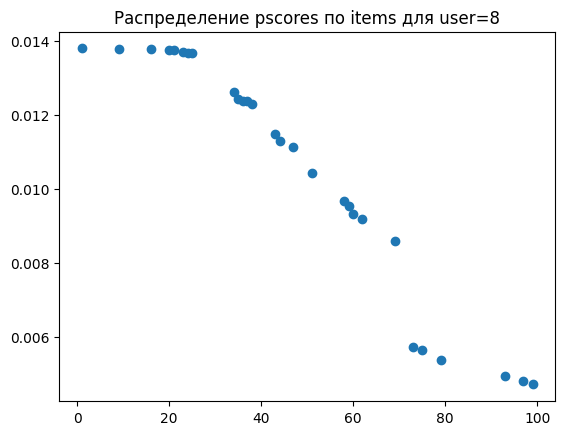

In [118]:
i = 8
plt.scatter(np.array(bandit_feedback_test['log'].toPandas()['item_idx'].tolist())[np.where(np.array(bandit_feedback_test['log'].toPandas()['user_idx'].tolist()) == i)], np.array(bandit_feedback_test['log'].toPandas()['pscore'].tolist())[np.where(np.array(bandit_feedback_test['log'].toPandas()['user_idx'].tolist()) == i)])
plt.title(f'Распределение pscores по items для user={i}')
plt.show()

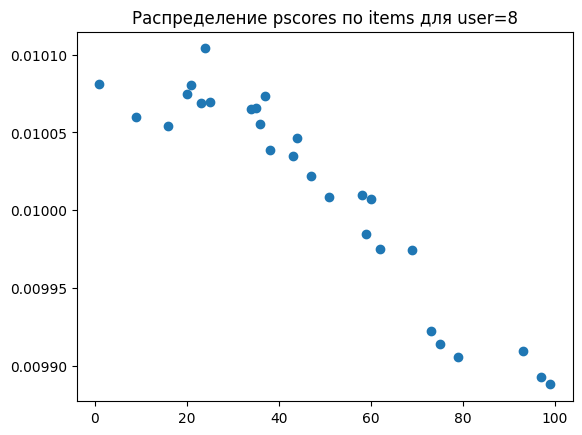

In [138]:
i = 8
plt.scatter(np.array(bandit_feedback_test['log'].toPandas()['item_idx'].tolist())[np.where(np.array(bandit_feedback_test['log'].toPandas()['user_idx'].tolist()) == i)], p_0[np.where(np.array(bandit_feedback_test['log'].toPandas()['user_idx'].tolist()) == i)])
plt.title(f'Распределение pscores по items для user={i}')
plt.show()

In [113]:
def ipw(pi_e, pi_0, r, r_hat):
    weights = pi_e/pi_0
    return weights * r

def snipw(pi_e, pi_0, r, r_hat):
    weights = pi_e/pi_0
    weights = weights/weights.mean()
    return weights * r
    
def sndr(pi_e, pi_0, r, r_hat, dm):
    weights = pi_e/pi_0
    weights = weights/weights.mean()
    return dm + weights*(r-r_hat)

def dm(dm):
    return dm


In [114]:
r_hat = estimated_rewards_by_reg_model[np.arange(bandit_feedback_test['action'].shape[0]), bandit_feedback_test['action'], 0]

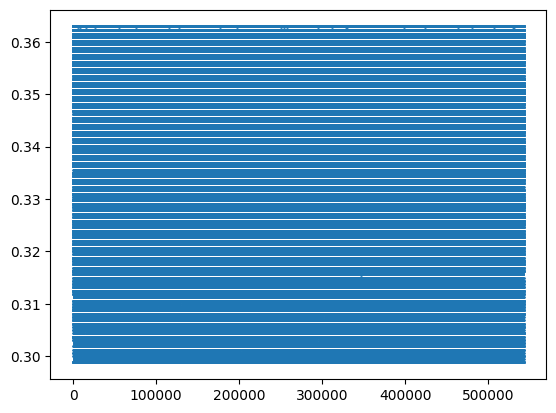

In [115]:
plt.scatter(np.arange(r_hat.size), r_hat, s = 1)

In [116]:
estimated_rewards_by_reg_model[0].shape

(100, 1)

In [117]:
DM_method_1 = (estimated_rewards_by_reg_model * all_action_dist_1).sum(axis = 1).squeeze()
DM_method_2 = (estimated_rewards_by_reg_model * all_action_dist_2).sum(axis = 1).squeeze()
DM_method_3 = (estimated_rewards_by_reg_model * all_action_dist_3).sum(axis = 1).squeeze()

In [118]:
DM_method_1

array([0.33086881, 0.33086867, 0.33086881, ..., 0.33086926, 0.33086862,
       0.33086942])

In [119]:
# np.save(f'DM_method_1', DM_method_1)
# np.save(f'DM_method_2', DM_method_2)
# np.save(f'DM_method_3', DM_method_3)

In [120]:
# all_action_dist_1 = np.load("UCB_policy.npy")
# all_action_dist_2 = np.load("Lin_UCB_policy.npy")
# all_action_dist_3 = np.load("Random_policy.npy")

In [121]:
all_action_dist_1_new = all_action_dist_1.copy()
for i in range(all_action_dist_1.shape[0]):
    all_action_dist_1_new[i][viewed_items_for_test[i]] = 0
    all_action_dist_1_new[i]/= all_action_dist_1_new[i].sum()

In [122]:
all_action_dist_2_new = all_action_dist_2.copy()
for i in range(all_action_dist_2.shape[0]):
    all_action_dist_2_new[i][viewed_items_for_test[i]] = 0
    all_action_dist_2_new[i]/= all_action_dist_2_new[i].sum()

In [123]:
all_action_dist_3_new = all_action_dist_3.copy()
for i in range(all_action_dist_3.shape[0]):
    all_action_dist_3_new[i][viewed_items_for_test[i]] = 0
    all_action_dist_3_new[i]/= all_action_dist_3_new[i].sum()

In [124]:
all_action_dist_1_top_10 = all_action_dist_1_new.copy()
idx_1 = np.argsort(-all_action_dist_1_top_10, axis = 1)
for i in range(all_action_dist_1_top_10.shape[0]):
    all_action_dist_1_top_10[i][idx_1[i][10:]] = 0
    all_action_dist_1_top_10[i] /= all_action_dist_1_top_10[i].sum()

In [125]:
all_action_dist_2_top_10 = all_action_dist_2_new.copy()
idx_2 = np.argsort(-all_action_dist_2_top_10, axis = 1)
for i in range(all_action_dist_2_top_10.shape[0]):
    all_action_dist_2_top_10[i][idx_2[i][10:]] = 0
    all_action_dist_2_top_10[i] /= all_action_dist_2_top_10[i].sum()

In [126]:
all_action_dist_3_top_10 = all_action_dist_3_new.copy()
idx_3 = np.argsort(-all_action_dist_3_top_10, axis = 1)
for i in range(all_action_dist_3_top_10.shape[0]):
    all_action_dist_3_top_10[i][idx_3[i][10:]] = 0
    all_action_dist_3_top_10[i] /= all_action_dist_3_top_10[i].sum()

In [127]:
all_action_dist_1_top_10[5].sum()

0.9999999999999999

In [128]:
DM_method_1_new = (estimated_rewards_by_reg_model * all_action_dist_1_new).sum(axis = 1).squeeze()
DM_method_2_new = (estimated_rewards_by_reg_model * all_action_dist_2_new).sum(axis = 1).squeeze()
DM_method_3_new = (estimated_rewards_by_reg_model * all_action_dist_3_new).sum(axis = 1).squeeze()

In [129]:
DM_method_1_top_10 = (estimated_rewards_by_reg_model * all_action_dist_1_top_10).sum(axis = 1).squeeze()
DM_method_2_top_10 = (estimated_rewards_by_reg_model * all_action_dist_2_top_10).sum(axis = 1).squeeze()
DM_method_3_top_10 = (estimated_rewards_by_reg_model * all_action_dist_3_top_10).sum(axis = 1).squeeze()

In [130]:
# DM_method_1 = np.load('DM_method_1.npy')
# DM_method_2 = np.load('DM_method_2.npy')
# DM_method_3 = np.load('DM_method_3.npy')

In [131]:
bandit_feedback_test['action'].shape

(543137,)

In [132]:
def run_exp(all_action_dist, DM_method):
    metrics = ['ipw', 'snipw', 'sndr', 'dm']
    pi_e = all_action_dist[np.arange(bandit_feedback_test['action'].shape[0]), bandit_feedback_test['action'], 0].copy()
    cnt_inner_bootstraps = 100
    _alpha = 0.05
    CIs = []
    prefixs = ['./sklearn_models/behavior_policies_sklearn']#['behavior_policies_full', 'behavior_policies_full_without_id_my_reg_mean', 'behavior_policies_full_without_id', 'behavior_policies_full_without_id_my_reg_mean_any_dist']
    for n_size in [100000, 200000, 300000, 400000, 500000]:
        res = {}
        pi_e_subset = pi_e[:n_size].copy()
        r_hat_subset = r_hat[:n_size].copy()
        r_subset = bandit_feedback_test['reward'][:n_size].copy()
        dm_subset = DM_method[:n_size].copy()
        stats = {}
        print(n_size)
        for metric in metrics:
            stats[metric] = []
        for prefix in prefixs:
            alpha = 0
            behavior_policies = np.load(f"{prefix}_25_alpha={alpha}.npy")
            for i in range(num_polices):
                pi_0_subset= behavior_policies[i][:n_size]

                ipw_est_round_rewards = ipw(pi_e_subset, pi_0_subset, r_subset, r_hat_subset)
                snipw_est_round_rewards = snipw(pi_e_subset, pi_0_subset, r_subset, r_hat_subset)
                sndr_est_round_rewards = sndr(pi_e_subset, pi_0_subset, r_subset, r_hat_subset, dm_subset)
                dm_est_round_rewards = dm(dm_subset)

                for j in range(cnt_inner_bootstraps):
                    bootstrap_idxs = np.random.randint(n_size, size=n_size)
                    stats['ipw'].append(ipw_est_round_rewards[bootstrap_idxs].mean())
                    stats['snipw'].append(snipw_est_round_rewards[bootstrap_idxs].mean())
                    stats['sndr'].append(sndr_est_round_rewards[bootstrap_idxs].mean())
                    stats['dm'].append(dm_est_round_rewards[bootstrap_idxs].mean())
                    
        for metric in metrics:
            dct = {}
            values = stats[metric]
            dct['mean'] = np.mean(values)
            dct['95.0% CI (lower)'] = np.percentile(values, 100 * (_alpha / 2))
            dct['95.0% CI (upper)'] = np.percentile(values, 100 * (1.0 - _alpha / 2))
            res[metric] = dct
        CIs.append(res)
    return CIs

In [133]:
CIs_1 = run_exp(all_action_dist_1, DM_method_1)

100000
200000
300000
400000
500000


In [134]:
CIs_2 = run_exp(all_action_dist_2, DM_method_2)

100000
200000
300000
400000
500000


In [135]:
CIs_3 = run_exp(all_action_dist_3, DM_method_3)

100000
200000
300000
400000
500000


In [136]:
CIs_1[-1]

{'ipw': {'mean': 0.3700942919290046,
  '95.0% CI (lower)': 0.36843528743992465,
  '95.0% CI (upper)': 0.3718382161318191},
 'snipw': {'mean': 0.3696033920673781,
  '95.0% CI (lower)': 0.36799667319305307,
  '95.0% CI (upper)': 0.37130843860640506},
 'sndr': {'mean': 0.36960715363019114,
  '95.0% CI (lower)': 0.36809393138531177,
  '95.0% CI (upper)': 0.3712006037363619},
 'dm': {'mean': 0.3308688709247605,
  '95.0% CI (lower)': 0.33086886993745884,
  '95.0% CI (upper)': 0.3308688718316774}}

In [137]:
CIs_2[-1]

{'ipw': {'mean': 0.34726588882257664,
  '95.0% CI (lower)': 0.3458280492907435,
  '95.0% CI (upper)': 0.34875466493547147},
 'snipw': {'mean': 0.34485484718588694,
  '95.0% CI (lower)': 0.34344580422545273,
  '95.0% CI (upper)': 0.34632616262753185},
 'sndr': {'mean': 0.3449429094577028,
  '95.0% CI (lower)': 0.3435592858018653,
  '95.0% CI (upper)': 0.3463473402691299},
 'dm': {'mean': 0.33236275693373,
  '95.0% CI (lower)': 0.3323593625940886,
  '95.0% CI (upper)': 0.33236624711289087}}

In [138]:
CIs_3[-1]

{'ipw': {'mean': 0.37730155920629593,
  '95.0% CI (lower)': 0.3757520570830328,
  '95.0% CI (upper)': 0.37892361752173637},
 'snipw': {'mean': 0.3768665178286316,
  '95.0% CI (lower)': 0.37532891258331713,
  '95.0% CI (upper)': 0.37846371531810874},
 'sndr': {'mean': 0.3768542889349578,
  '95.0% CI (lower)': 0.3754069076836318,
  '95.0% CI (upper)': 0.37835529529141},
 'dm': {'mean': 0.3374984030146512,
  '95.0% CI (lower)': 0.3374984020826725,
  '95.0% CI (upper)': 0.33749840400180486}}

In [139]:
def plot_CIs(CIs_1, CIs_2, CIs_3, model_1, model_2, model_3):
    fig, ax = plt.subplots(4, figsize=(10, 10))
    
    x = [100000, 200000, 300000, 400000, 500000]

    colors = ['b', 'r', 'g', 'y']
    i = 0 
    for name in ['ipw', 'dm', 'sndr', 'snipw']:
        y_est = [estimated_ci[name]["mean"] for estimated_ci in CIs_1]
        y_up = [estimated_ci[name]["95.0% CI (upper)"] for estimated_ci in CIs_1]
        y_low = [estimated_ci[name]["95.0% CI (lower)"] for estimated_ci in CIs_1]
        
        ax[i].plot(x, y_est, '-', label=model_1, color = colors[0])
        ax[i].fill_between(x, y_low, y_up, alpha=0.2, color = colors[0])
        
        y_est = [estimated_ci[name]["mean"] for estimated_ci in CIs_2]
        y_up = [estimated_ci[name]["95.0% CI (upper)"] for estimated_ci in CIs_2]
        y_low = [estimated_ci[name]["95.0% CI (lower)"] for estimated_ci in CIs_2]
        
        ax[i].plot(x, y_est, '-', label=model_2, color = colors[1])
        ax[i].fill_between(x, y_low, y_up, alpha=0.2, color = colors[1])
        
        y_est = [estimated_ci[name]["mean"] for estimated_ci in CIs_3]
        y_up = [estimated_ci[name]["95.0% CI (upper)"] for estimated_ci in CIs_3]
        y_low = [estimated_ci[name]["95.0% CI (lower)"] for estimated_ci in CIs_3]
        
        ax[i].plot(x, y_est, '-', label=model_3, color = colors[2])
        ax[i].fill_between(x, y_low, y_up, alpha=0.2, color = colors[2])
        
        ax[i].set_title(name)
        i+=1

    fig.suptitle("OPE for " + " " + model_1 + " " + model_2 + " " + model_2, fontsize=16)
    fig.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()

In [140]:
users_train = np.unique(bandit_feedback_train['log'].toPandas()['user_idx'].values)

In [141]:
users_test = np.unique(bandit_feedback_test['log'].toPandas()['user_idx'].values)

In [142]:
cold_users = []
for u in  users_test:
    if not (u in users_train):
        cold_users.append(u)
cold_users = np.array(cold_users)

INFO:root:Exception while sending command.
Traceback (most recent call last):
  File "/home/sudakovcom/Desktop/RePlayHDILab2024/.conda/lib/python3.8/site-packages/py4j/clientserver.py", line 503, in send_command
    self.socket.sendall(command.encode("utf-8"))
ConnectionResetError: [Errno 104] Connection reset by peer

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/sudakovcom/Desktop/RePlayHDILab2024/.conda/lib/python3.8/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/home/sudakovcom/Desktop/RePlayHDILab2024/.conda/lib/python3.8/site-packages/py4j/clientserver.py", line 506, in send_command
    raise Py4JNetworkError(
py4j.protocol.Py4JNetworkError: Error while sending


In [143]:
cold_users

array([], dtype=float64)

In [144]:
not_cold_idx = (bandit_feedback_test['log'].toPandas()['user_idx'].isin(cold_users)).values

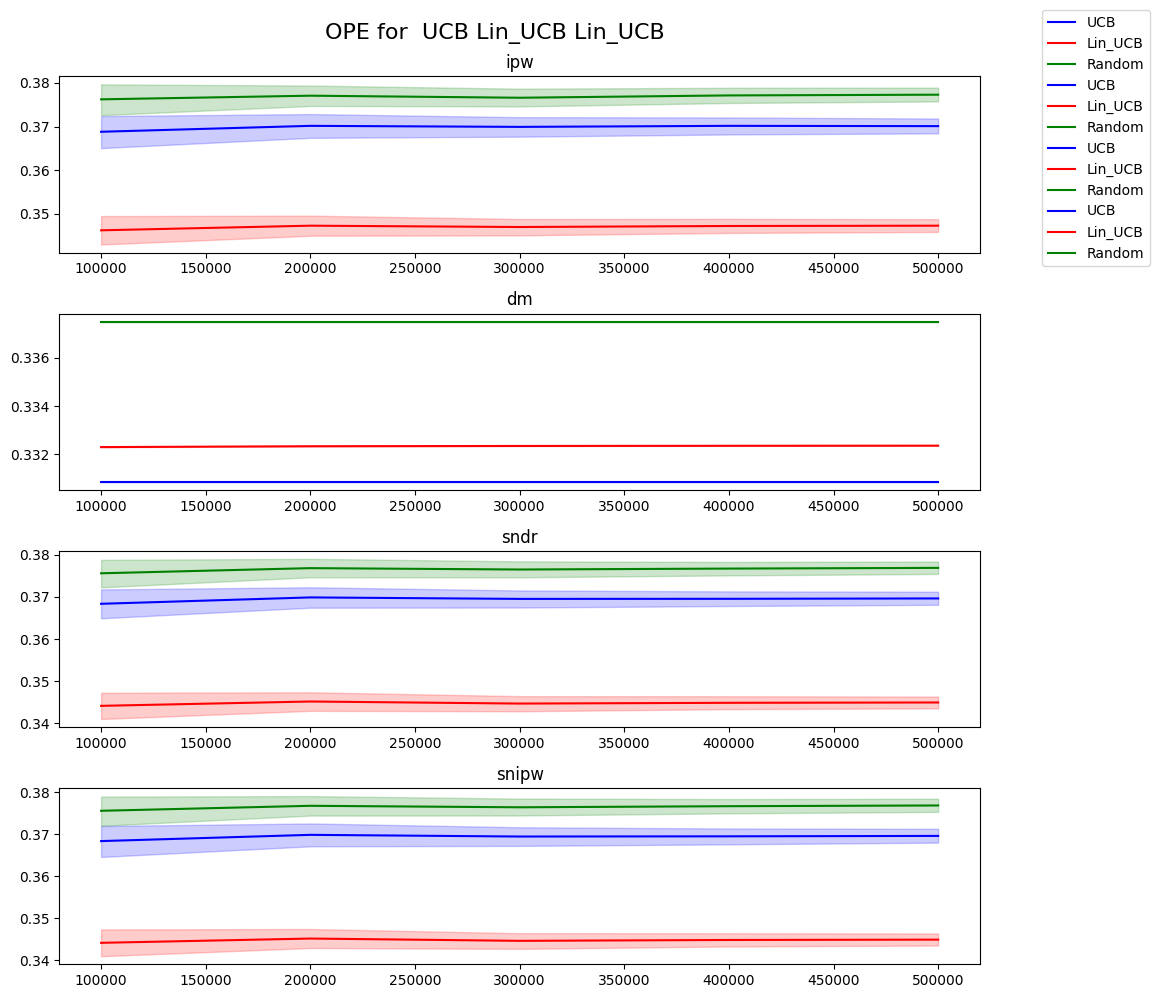

In [145]:
plot_CIs(CIs_1,CIs_2, CIs_3, 'UCB', 'Lin_UCB', 'Random')

In [150]:
def plot_join_res(CIs, model):
    fig, ax = plt.subplots(figsize=(10, 10))
    
    x = [100000, 200000, 300000, 400000, 500000]
        
    colors = ['b', 'r', 'g', 'y', 'aqua', 'pink', 'orange']
    i = 0
    for name in ['ipw', 'dm', 'sndr', 'snipw']:
        y_est = [estimated_ci[name]["mean"] for estimated_ci in CIs]
        y_up = [estimated_ci[name]["95.0% CI (upper)"] for estimated_ci in CIs]
        y_low = [estimated_ci[name]["95.0% CI (lower)"] for estimated_ci in CIs]

        ax.plot(x, y_est, '-', label=name, color = colors[i])
        ax.fill_between(x, y_low, y_up, alpha=0.2, color = colors[i])
        #ax.plot(x, y, 'o', color='tab:brown')
        i=i+1
    fig.suptitle("OPE for " + model, fontsize=16)
    fig.legend()

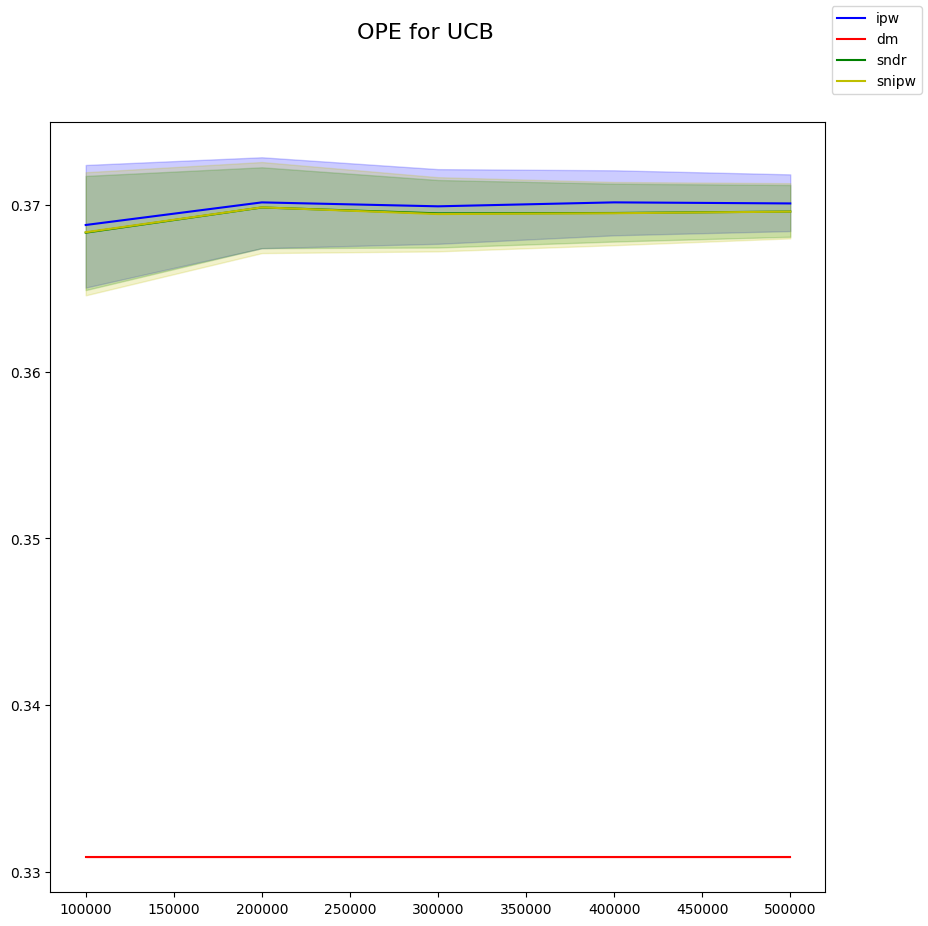

In [151]:
plot_join_res(CIs_1, 'UCB')

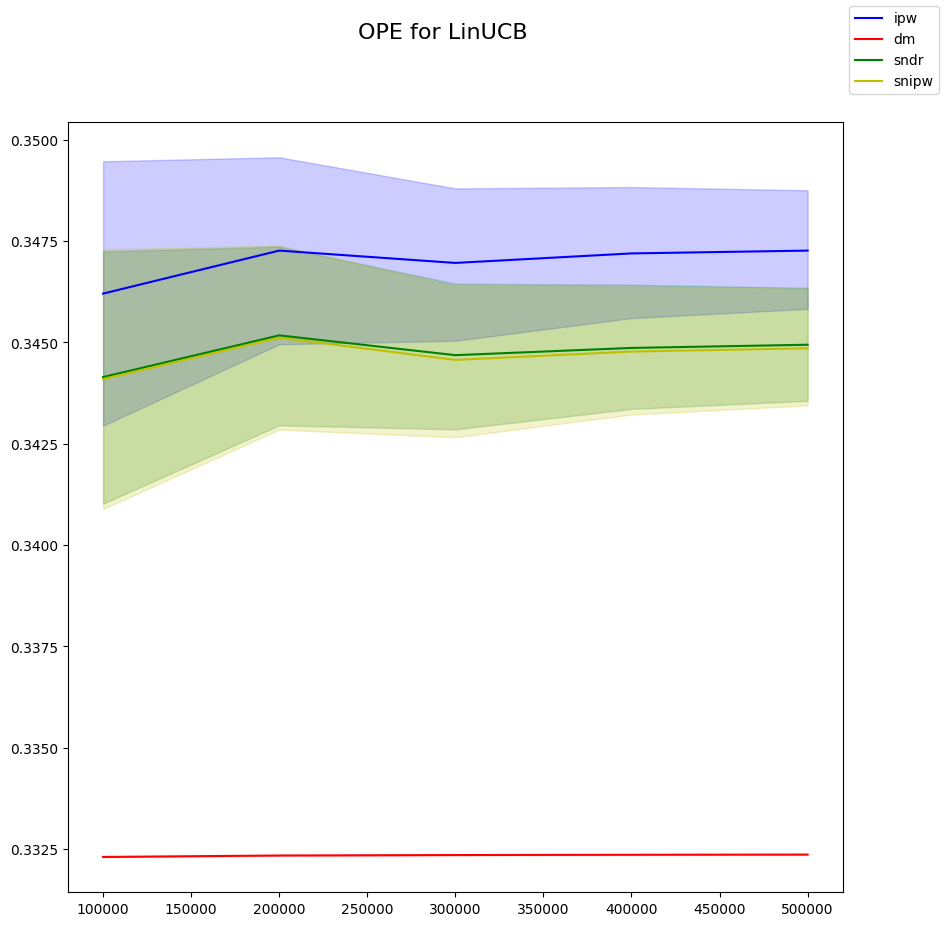

In [152]:
plot_join_res(CIs_2, 'LinUCB')

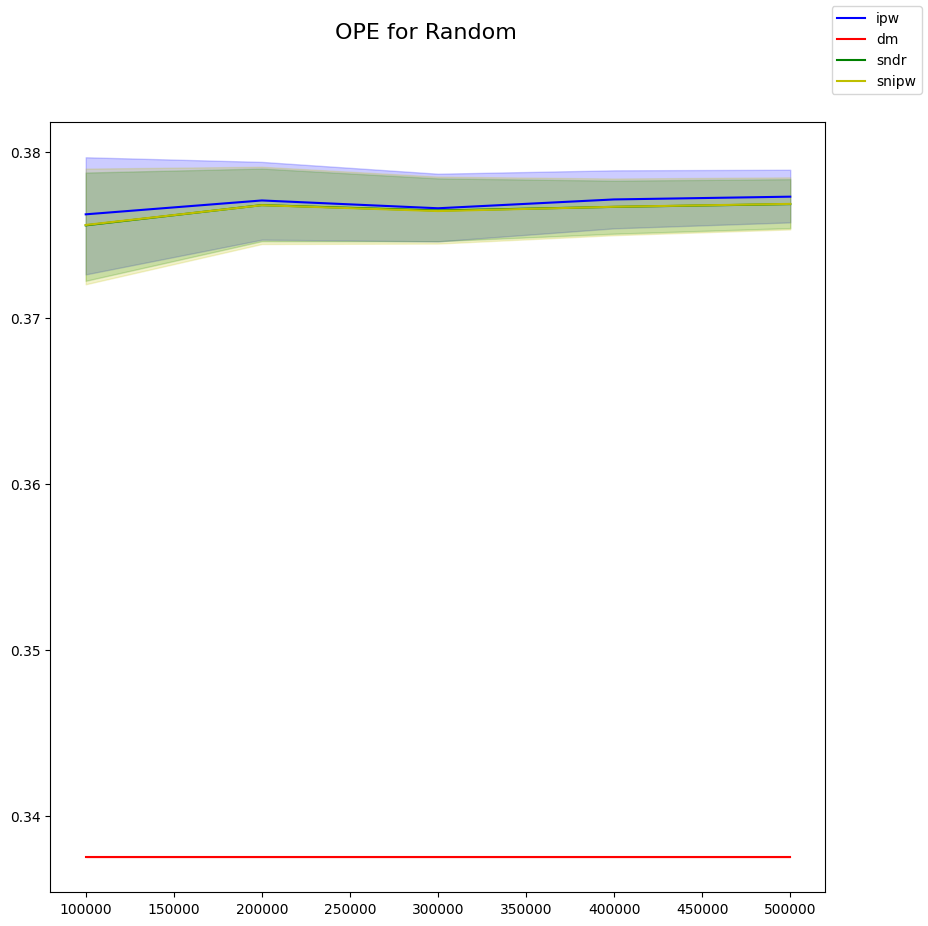

In [153]:
plot_join_res(CIs_3, 'Random')

In [154]:
learner_1.predict_and_evaluate_new(bandit_feedback_test, K=10)

100%|██████████| 2296/2296 [07:33<00:00,  5.07it/s]                             


{'hr@10': 0.5096884493406179,
 'mrr@10': 0.17338762705819946,
 'ndcg@10': 0.25299053208823574,
 'cov@10': 1.0}

In [155]:
learner_2.predict_and_evaluate_new(bandit_feedback_test, K=10)

100%|██████████| 2296/2296 [03:51<00:00,  9.93it/s]


{'hr@10': 0.6321517283816849,
 'mrr@10': 0.24877563008315215,
 'ndcg@10': 0.33882252300277,
 'cov@10': 1.0}

In [156]:
learner_3.predict_and_evaluate_new(bandit_feedback_test, K=10)

  4%|▍         | 93/2296 [00:17<06:43,  5.46it/s]

100%|██████████| 2296/2296 [07:26<00:00,  5.15it/s]


{'hr@10': 0.26649467291426915,
 'mrr@10': 0.07783534650311316,
 'ndcg@10': 0.12090732001745493,
 'cov@10': 1.0}

In [157]:
my_log = bandit_feedback_test['log'].toPandas().copy()
check_map_pop_dist = my_log['item_idx'].value_counts(normalize=True)
check_pop_dist =[]
for a in range(bandit_feedback_test['n_actions']):
    if a in bandit_feedback_test['action']:
        check_pop_dist.append(check_map_pop_dist.loc[[a]].values[0])
    else:
        check_pop_dist.append(0)

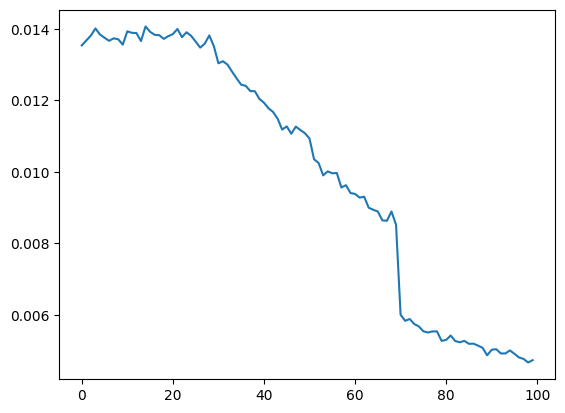

In [158]:
plt.plot(np.arange(bandit_feedback_test['n_actions']), check_pop_dist)

In [159]:
my_log = bandit_feedback_train['log'].toPandas().copy()
check_map_pop_dist = my_log['item_idx'].value_counts(normalize=True)
check_pop_dist =[]
for a in range(bandit_feedback_train['n_actions']):
    if a in bandit_feedback_train['action']:
        check_pop_dist.append(check_map_pop_dist.loc[[a]].values[0])
    else:
        check_pop_dist.append(0)

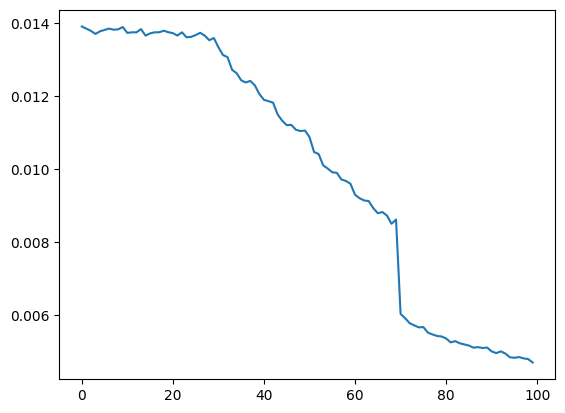

In [160]:
plt.plot(np.arange(bandit_feedback_test['n_actions']), check_pop_dist)

In [161]:
print('done')

done
